In [78]:
%load_ext cuml.accel

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , OneHotEncoder , FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer , make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split , cross_val_score , cross_val_predict
from sklearn.metrics import f1_score , precision_score , recall_score , make_scorer , precision_recall_curve , roc_curve
from sklearn.model_selection import GridSearchCV


In [80]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]
df= pd.read_table('/kaggle/input/datasets/muhammadshoaibjamali/adult-data/adult.data' , names=columns , sep=',')

In [81]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [82]:
df.shape

(32561, 15)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [84]:
for col in df.select_dtypes(include=['object' , 'category']).columns:
    df[col] = df[col].str.strip()

In [85]:
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [86]:
df = df.drop(columns='fnlwgt' , axis=1)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
df['works-overtime'] = np.where(df['hours-per-week'] > 40 , 'yes' , 'no')
df['native-country'] = df['native-country'].apply(
    lambda x: 'United-States' if x == 'United-States' else 'Other'
)

print(df['native-country'].value_counts())
df.head()

native-country
United-States    29170
Other             3391
Name: count, dtype: int64


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,works-overtime
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0,no
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0,no
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0,no
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0,no
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Other,0,no


In [87]:
cat_columns = df.select_dtypes(include=['object' , 'category']).columns
for col in cat_columns:
    df[col] = df[col].replace('?' , np.nan)

In [88]:
df.isna().sum()

age                  0
workclass         1836
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country       0
income               0
works-overtime       0
dtype: int64

In [89]:
missing_cols = ['workclass' , 'occupation' , 'native-country']
for col in missing_cols:
    df[col] = df[col].replace(np.nan , df[col].mode()[0])

In [90]:
df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [91]:
def remove_outliers(df , columns):
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr =  q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
    return (df[(df[col] >= lower_bound) & (df[col] <= upper_bound)])

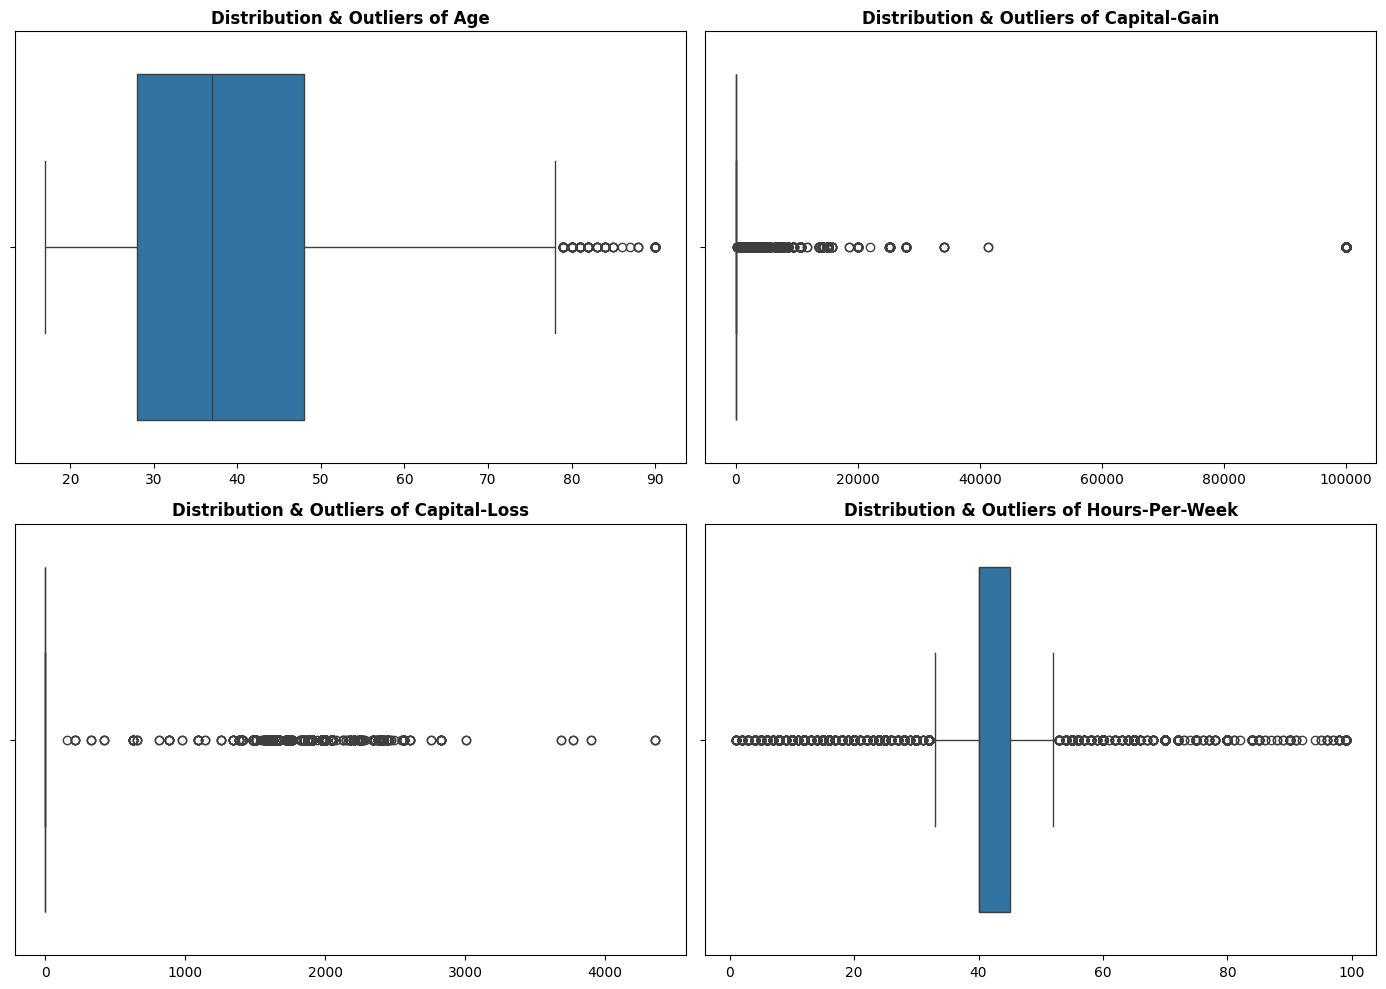

In [92]:
numerical_cols = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution & Outliers of {col.title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  

plt.tight_layout()
plt.show()

In [93]:
df = remove_outliers(df , ['age' , 'hours-per-week'])

In [94]:
df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,works-overtime
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0,no
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0,no
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0,no
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Other,0,no
5,37,Private,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,0,no


In [95]:
X = df.drop(columns='income',axis=1)
y = df['income']

In [96]:
X_train , X_test , y_train , y_test = train_test_split(X , y , stratify=y , random_state=42)

In [97]:
num_pipeline = make_pipeline(
    StandardScaler()
)

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown='ignore' , sparse_output=False)
)

preprocessing = ColumnTransformer([
    ('num' , num_pipeline , make_column_selector(dtype_include=np.number)),
    ('cat' , cat_pipeline , make_column_selector(dtype_include=['object' , 'category']))
])


In [98]:
prepared_data = preprocessing.fit_transform(X_train)

In [99]:
df_prepared_data = pd.DataFrame(prepared_data , columns=preprocessing.get_feature_names_out() , index=X_train.index)

In [100]:
df_prepared_data.head()

,num__age,num__education-num,num__capital-gain,num__capital-loss,num__hours-per-week,cat__workclass_Federal-gov,cat__workclass_Local-gov,cat__workclass_Never-worked,cat__workclass_Private,cat__workclass_Self-emp-inc,...,cat__race_Asian-Pac-Islander,cat__race_Black,cat__race_Other,cat__race_White,cat__sex_Female,cat__sex_Male,cat__native-country_Other,cat__native-country_United-States,cat__works-overtime_no,cat__works-overtime_yes
18999,-1.197520,1.144399,-0.149008,-0.218726,-0.384252,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
31882,0.257711,1.144399,-0.149008,-0.218726,-0.384252,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
4045,-0.793289,0.355503,-0.149008,-0.218726,1.607218,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
4893,-0.712443,-0.433392,-0.149008,-0.218726,-0.384252,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
25700,-0.954981,1.933295,-0.149008,-0.218726,-0.384252,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0


In [101]:
forest_model = make_pipeline(preprocessing , RandomForestClassifier())
forest_model.fit(X_train , y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f8a51bfe060>),
                                                 ('cat',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f8a51bff140>)])),
                ('randomforestclassifier', RandomForestClassifier())])

In [102]:
y_pred = forest_model.predict(X_test)

In [103]:
print(f1_score(y_test , y_pred))
print(precision_score(y_test , y_pred))
print(recall_score(y_test , y_pred))

0.6791072081961215
0.7538586515028433
0.6178428761651131


In [104]:
param_grid = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [15, 25, None], 
    'randomforestclassifier__min_samples_leaf': [2, 5, 10], 
    'randomforestclassifier__max_features': ['sqrt', 'log2']
}

In [105]:
custom_f1_scorer = make_scorer(f1_score, pos_label='>50K')

grid_search = GridSearchCV(
    estimator=forest_model, 
    param_grid=param_grid, 
    scoring='f1',  
    cv=3, 
    n_jobs=-1, 
    verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END randomforestclassifier__max_depth=15, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=2, randomforestclassifier__n_estimators=100; total time=   2.4s
[CV] END randomforestclassifier__max_depth=15, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=5, randomforestclassifier__n_estimators=100; total time=   1.7s
[CV] END randomforestclassifier__max_depth=15, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=5, randomforestclassifier__n_estimators=100; total time=   1.1s
[CV] END randomforestclassifier__max_depth=15, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=5, randomforestclassifier__n_estimators=200; total time=   3.3s
[CV] END randomforestclassifier__max_depth=15, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=10, randomforestclassifier_

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('standardscaler',
                                                                                          StandardScaler())]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7f8a51bfe060>),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         <sklearn...e_column_selector object at 0x7f8a51bff140>)])),
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': [15, 25, None],
                         'randomforestclassifier__max_features': ['sqrt',
                                                                  'log2'],
                         'randomforestclassifier__min_samples_leaf': [2, 5, 10],
                         'randomforestclassifier__n_estimators': [100, 200]},
             scoring='f1', verbose=2)

In [106]:
best_estimator = grid_search.best_estimator_

In [107]:
y_pred = best_estimator.predict(X_test)

In [108]:
print(f1_score(y_test , y_pred))
print(recall_score(y_test , y_pred))
print(precision_score(y_test , y_pred))

0.6823529411764706
0.6371504660452729
0.7344589409056025


In [109]:
predict_proba = grid_search.predict_proba(X_test)

In [110]:
y_score_forest = predict_proba[: , 1]

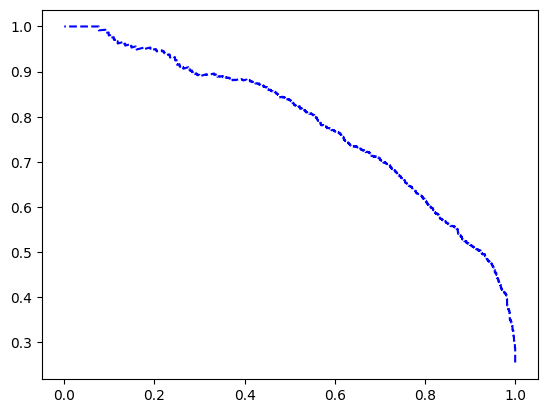

In [111]:
precision_forest , recall_forest , threshold_forest = precision_recall_curve(y_test , y_score_forest)
plt.plot(recall_forest , precision_forest , 'b--')

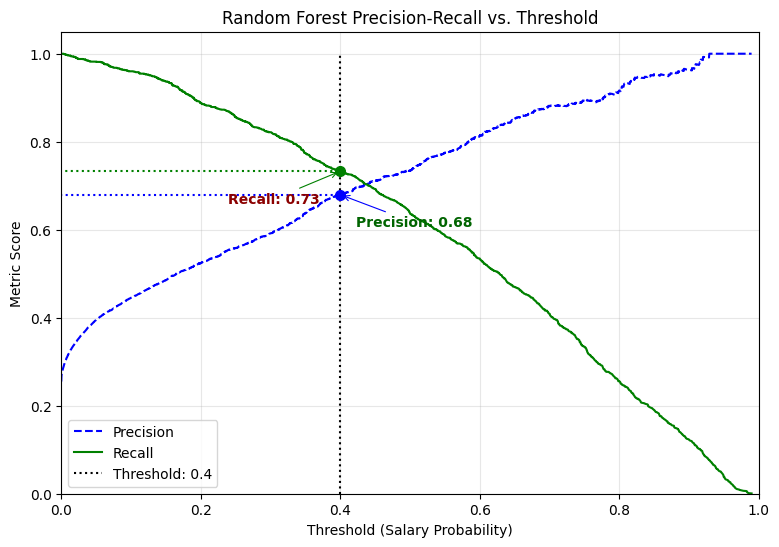

In [112]:
optimal_threshold = 0.4
plt.figure(figsize=(9, 6))
plt.plot(threshold_forest, precision_forest[:-1], 'b--', label='Precision', linewidth=1.5)
plt.plot(threshold_forest, recall_forest[:-1], 'g', label='Recall', linewidth=1.5)
plt.vlines(optimal_threshold, 0, 1, 'k', 'dotted', label=f'Threshold: {optimal_threshold}')

idx_forest = np.argmin(np.abs(threshold_forest - optimal_threshold))
p = precision_forest[idx_forest]
r = recall_forest[idx_forest]

plt.plot(optimal_threshold, p, 'bo', markersize=7)
plt.plot(optimal_threshold, r, 'go', markersize=7)

plt.hlines(p, plt.xlim()[0], optimal_threshold, color='b', linestyle='dotted')
plt.hlines(r, plt.xlim()[0], optimal_threshold, color='g', linestyle='dotted')

plt.annotate(
    f"Recall: {r:.2f}",
    xy=(optimal_threshold, r),
    xytext=(-15, -15),          
    textcoords="offset points",
    ha="right",
    va="top",
    color="darkred",
    weight="bold",
    arrowprops=dict(arrowstyle="->", color="green", lw=0.8)
)

plt.annotate(
    f"Precision: {p:.2f}",
    xy=(optimal_threshold, p),
    xytext=(95, -15),
    textcoords='offset points',
    ha='right',
    va='top',
    color='darkgreen',
    weight='bold',
    arrowprops=dict(arrowstyle='->', color='blue', lw=0.8)
)

plt.xlabel("Threshold (Salary Probability)")
plt.ylabel("Metric Score")
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left")
plt.title("Random Forest Precision-Recall vs. Threshold")
plt.show()

In [113]:
y_score_forest = grid_search.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9]

for t in thresholds:
    y_test_pred = y_score_forest >= t
    f1score = f1_score(y_test, y_test_pred)
    print(f'Threshold: {t:<4} | True Test F1-Score: {f1score:.4f}')

Threshold: 0.1  | True Test F1-Score: 0.6086
Threshold: 0.2  | True Test F1-Score: 0.6593
Threshold: 0.3  | True Test F1-Score: 0.6880
Threshold: 0.35 | True Test F1-Score: 0.6989
Threshold: 0.4  | True Test F1-Score: 0.7053
Threshold: 0.45 | True Test F1-Score: 0.7020
Threshold: 0.5  | True Test F1-Score: 0.6824
Threshold: 0.6  | True Test F1-Score: 0.6447
Threshold: 0.7  | True Test F1-Score: 0.5584
Threshold: 0.8  | True Test F1-Score: 0.3990
Threshold: 0.9  | True Test F1-Score: 0.2174


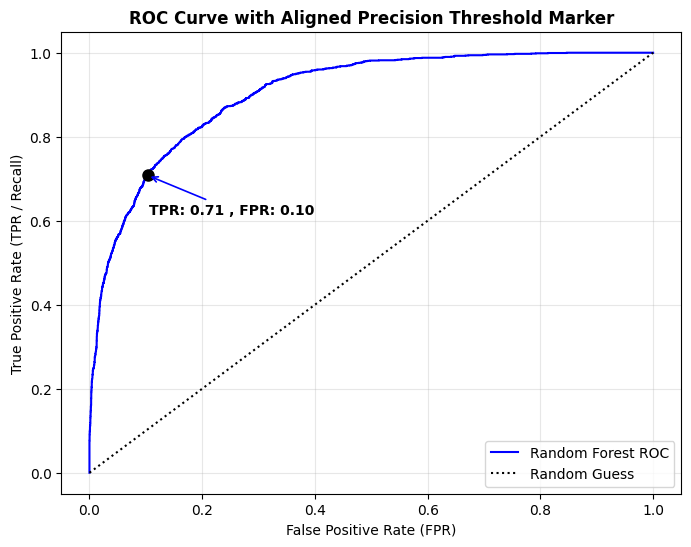

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_forest, tpr_forest, thresholds_roc_curve_forest = roc_curve(y_test, y_score_forest)

idx_for_70_precision = (precision_forest >= 0.70).argmax()
threshold_for_70_precision = threshold_forest[idx_for_70_precision]

idx_for_roc = np.argmin(np.abs(thresholds_roc_curve_forest - threshold_for_70_precision))
tpr_90 = tpr_forest[idx_for_roc]
fpr_90 = fpr_forest[idx_for_roc]

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='Random Forest ROC', color='blue')
plt.plot([0, 1], [0, 1], 'k', linestyle='dotted', label='Random Guess')
plt.plot([fpr_90], [tpr_90], 'ko', markersize=8)

plt.annotate(
    f'TPR: {tpr_90:.2f} , FPR: {fpr_90:.2f}',
    xy=(fpr_90, tpr_90),
    xytext=(120, -20),
    textcoords='offset points',
    ha='right',
    va='top',
    weight='bold',
    arrowprops=dict(arrowstyle='->', color='blue', lw=1.2)
)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('ROC Curve with Aligned Precision Threshold Marker', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()

In [115]:
!pip install -q gradio

import gradio as gr
import pandas as pd
import numpy as np

In [116]:
import gradio as gr
import pandas as pd
import numpy as np

def predict_salary(age, workclass, education, marital_status, occupation, relationship, race, sex, capital_gain, capital_loss, hours_per_week, native_country):
    
    derived_overtime_str = "yes" if int(hours_per_week) > 40 else "no"
    
    row_data = [
        int(age),
        str(workclass).strip(),
        str(education).strip(),
        int(10),                                
        str(marital_status).strip(),
        str(occupation).strip(),
        str(relationship).strip(),
        str(race).strip(),
        str(sex).strip(),
        float(capital_gain),
        float(capital_loss),
        int(hours_per_week),
        derived_overtime_str,                  
        str(native_country).strip()
    ]
    
    column_names = [
        'age', 'workclass', 'education', 'education-num', 'marital-status',
        'occupation', 'relationship', 'race', 'sex', 'capital-gain',
        'capital-loss', 'hours-per-week', 'works-overtime', 'native-country'
    ]
    
    input_data = pd.DataFrame([row_data], columns=column_names)

    original_isnan = np.isnan
    def safe_isnan(x, *args, **kwargs):
        try:
            if isinstance(x, np.ndarray) and x.dtype == object:
                return np.array([isinstance(el, (float, int)) and original_isnan(el) for el in x])
            return original_isnan(x, *args, **kwargs)
        except TypeError:
            return np.zeros_like(x, dtype=bool)
    
    np.isnan = safe_isnan

    try:
        prob_high_earner = grid_search.predict_proba(input_data)[0, 1]
    except ValueError as e:
        if "invalid literal for int()" in str(e) or "could not convert string" in str(e):
            input_data['works-overtime'] = int(1 if int(hours_per_week) > 40 else 0)
            prob_high_earner = grid_search.predict_proba(input_data)[0, 1]
        else:
            raise e
    finally:
        np.isnan = original_isnan
    
    OPTIMAL_THRESHOLD = 0.40
    prediction = "Income >50K (High Earner)" if prob_high_earner >= OPTIMAL_THRESHOLD else "Income <=50K (Low Earner)"
    
    confidences = {
        "Income <=50K": float(1 - prob_high_earner),
        "Income >50K": float(prob_high_earner)
    }
    
    return prediction, confidences


with gr.Blocks(theme="soft") as demo:
    
    gr.Markdown(
        """
        # 📊 Census Income Prediction Dashboard
        ### Optimized Random Forest Classifier Engine (Threshold = 0.40)
        """
    )
    
    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown("### 👤 Employee Demographics & Background")
            with gr.Row():
                age = gr.Slider(minimum=17, maximum=90, value=35, step=1, label="Age")
                sex = gr.Radio(choices=["Male", "Female"], value="Male", label="Sex")
                race = gr.Dropdown(choices=["White", "Black", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"], value="White", label="Race")
            
            with gr.Row():
                marital_status = gr.Dropdown(choices=["Married-civ-spouse", "Never-married", "Divorced", "Separated", "Widowed", "Married-spouse-absent", "Married-AF-spouse"], value="Never-married", label="Marital Status")
                relationship = gr.Dropdown(choices=["Husband", "Not-in-family", "Own-child", "Unmarried", "Wife", "Other-relative"], value="Not-in-family", label="Relationship Status")

            gr.Markdown("### 💼 Employment Details")
            with gr.Row():
                workclass = gr.Dropdown(choices=["Private", "Self-emp-not-inc", "Self-emp-inc", "Federal-gov", "Local-gov", "State-gov", "Without-pay", "Never-worked"], value="Private", label="Workclass")
                education = gr.Dropdown(choices=["HS-grad", "Some-college", "Bachelors", "Masters", "Doctorate", "Assoc-voc", "Assoc-acdm", "11th", "10th", "7th-8th", "Prof-school", "9th", "12th", "5th-6th", "1st-4th", "Preschool"], value="Bachelors", label="Education Level")
            
            with gr.Row():
                occupation = gr.Dropdown(choices=["Prof-specialty", "Craft-repair", "Exec-managerial", "Adm-clerical", "Sales", "Other-service", "Machine-op-inspct", "Transport-moving", "Handlers-cleaners", "Farming-fishing", "Tech-support", "Protective-serv", "Priv-house-serv", "Armed-Forces"], value="Prof-specialty", label="Occupation Role")
                hours_per_week = gr.Slider(minimum=1, maximum=99, value=40, step=1, label="Hours Worked Per Week")

            gr.Markdown("### 📈 Capital & Financial Metrics")
            with gr.Row():
                capital_gain = gr.Number(value=0, label="Capital Gains ($)")
                capital_loss = gr.Number(value=0, label="Capital Losses ($)")
                native_country = gr.Dropdown(choices=["United-States", "Cuba", "Jamaica", "India", "Mexico", "South", "Puerto-Rico", "Honduras", "England", "Canada", "Germany", "Iran", "Philippines", "Italy", "Poland", "Columbia", "Cambodia", "Thailand", "Ecuador", "Laos", "Taiwan", "Haiti", "Portugal", "Dominican-Republic", "El-Salvador", "France", "Guatemala", "China", "Japan", "Yugoslavia", "Peru", "Outlying-US(Guam-USVI-etc)", "Scotland", "Trinadad&Tobago", "Greece", "Nicaragua", "Vietnam", "Hong", "Ireland", "Hungary", "Holand-Netherlands"], value="United-States", label="Native Country")
            
            submit_btn = gr.Button("🚀 Run Pipeline Prediction", variant="primary")

        with gr.Column(scale=1):
            gr.Markdown("### 🎯 Model Inference Output")
            output_label = gr.Textbox(label="Classification Decision (Threshold Aligned)", interactive=False)
            output_chart = gr.Label(label="Class Probability Confidence Distribution")

    submit_btn.click(
        fn=predict_salary,
        inputs=[age, workclass, education, marital_status, occupation, relationship, race, sex, capital_gain, capital_loss, hours_per_week, native_country],
        outputs=[output_label, output_chart]
    )

demo.launch(inline=True, share=True)

/tmp/ipykernel_58/3343860166.py:67: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme="soft") as demo:


* Running on local URL:  http://127.0.0.1:7870
* Running on public URL: https://7c2732723383bf8788.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
